In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load datasets
matches = pd.read_csv('data/matches.csv')
deliveries = pd.read_csv('data/deliveries.csv')

print("Matches dataset:", matches.shape)
print("Deliveries dataset:", deliveries.shape)
print("\nMatches columns:", matches.columns.tolist())

Matches dataset: (1095, 20)
Deliveries dataset: (260920, 17)

Matches columns: ['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']


In [2]:
# Basic exploration
print("Seasons available:", sorted(matches['season'].unique()))
print("\nTotal teams:", matches['team1'].nunique())
print("\nTop 10 venues:\n", matches['venue'].value_counts().head(10))
print("\nMissing values:\n", matches.isnull().sum())

Seasons available: ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']

Total teams: 19

Top 10 venues:
 venue
Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         65
Feroz Shah Kotla                              60
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Stadium, Chepauk               48
Sawai Mansingh Stadium                        47
Dubai International Cricket Stadium           46
Wankhede Stadium, Mumbai                      45
Punjab Cricket Association Stadium, Mohali    35
Name: count, dtype: int64

Missing values:
 id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision        

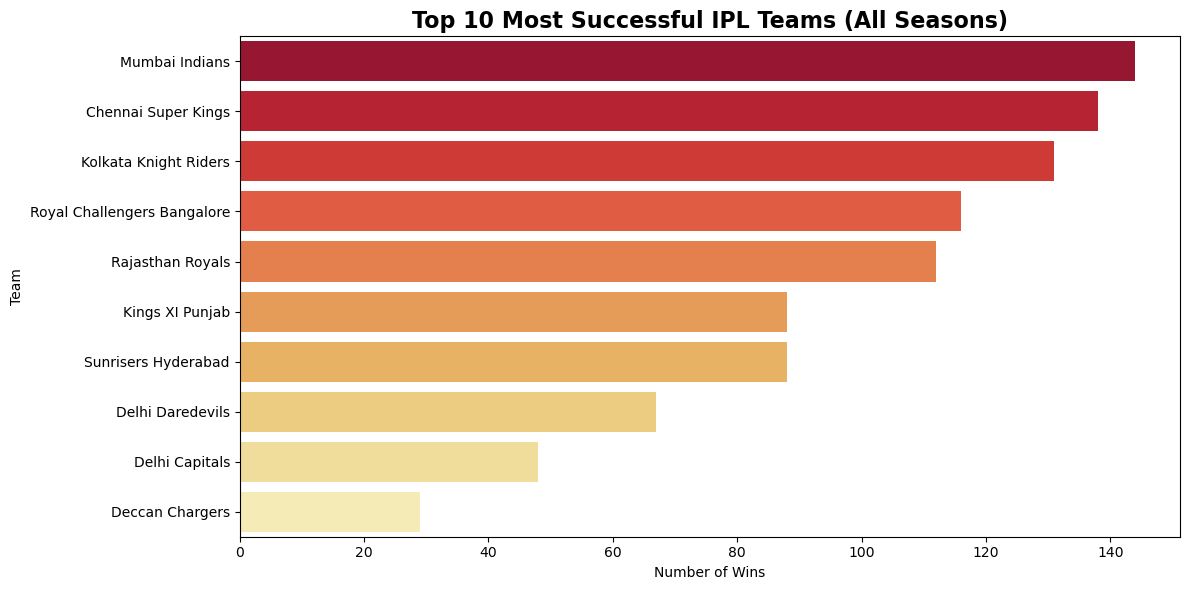

Done! Plot 1 saved!


In [4]:
matches['season'] = matches['season'].replace({
    '2007/08': '2008', '2009/10': '2010', '2020/21': '2021'
})
matches['season'] = matches['season'].astype(int)

win_counts = matches['winner'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=win_counts.values, y=win_counts.index, palette='YlOrRd_r')
plt.title('Top 10 Most Successful IPL Teams (All Seasons)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.savefig('data/plot1_team_wins.png', dpi=150)
plt.show()
print("Done! Plot 1 saved!")

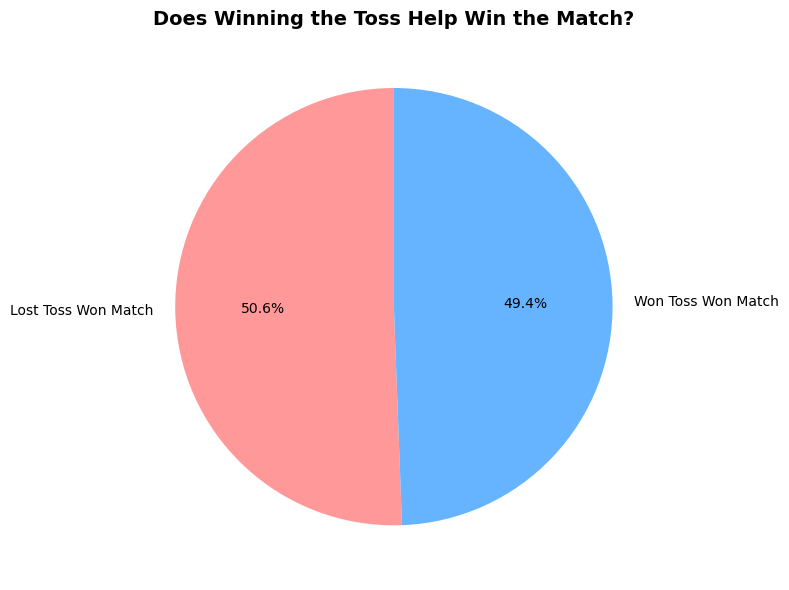

Done! Plot 2 saved!


In [5]:
# Analysis 2 - Toss impact on winning
matches['toss_win_match_win'] = matches['toss_winner'] == matches['winner']
toss_impact = matches['toss_win_match_win'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(toss_impact.values, 
        labels=['Lost Toss Won Match', 'Won Toss Won Match'],
        autopct='%1.1f%%',
        colors=['#ff9999','#66b3ff'],
        startangle=90)
plt.title('Does Winning the Toss Help Win the Match?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/plot2_toss_impact.png', dpi=150)
plt.show()
print("Done! Plot 2 saved!")

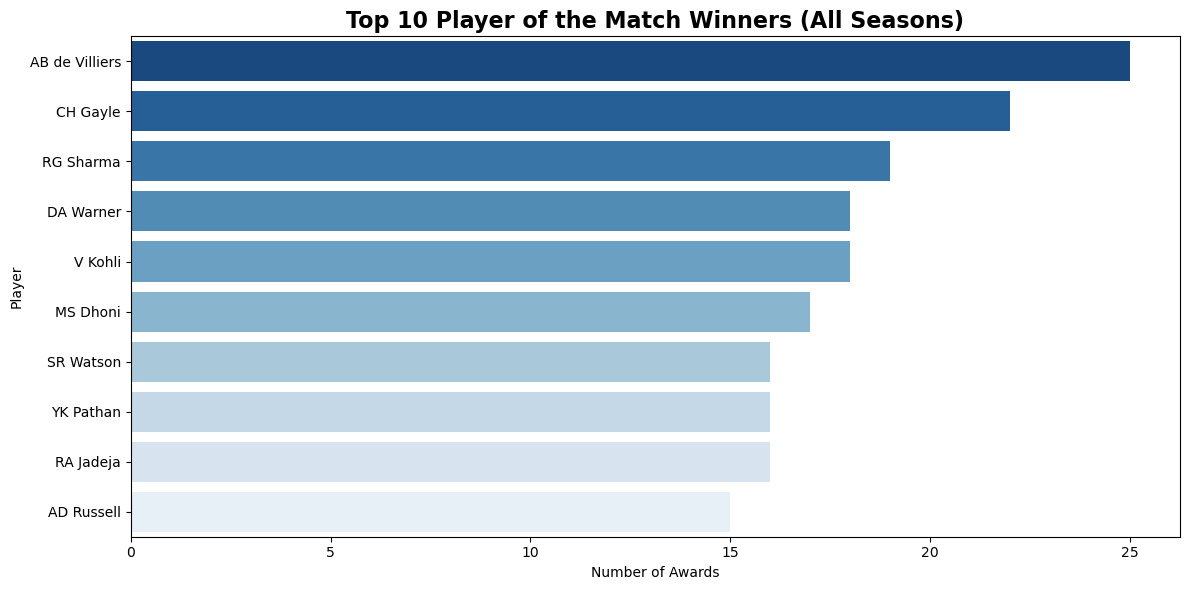

Done! Plot 3 saved!


In [6]:
# Analysis 3 - Top 10 Player of the Match awards
top_players = matches['player_of_match'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_players.values, y=top_players.index, palette='Blues_r')
plt.title('Top 10 Player of the Match Winners (All Seasons)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Awards')
plt.ylabel('Player')
plt.tight_layout()
plt.savefig('data/plot3_top_players.png', dpi=150)
plt.show()
print("Done! Plot 3 saved!")

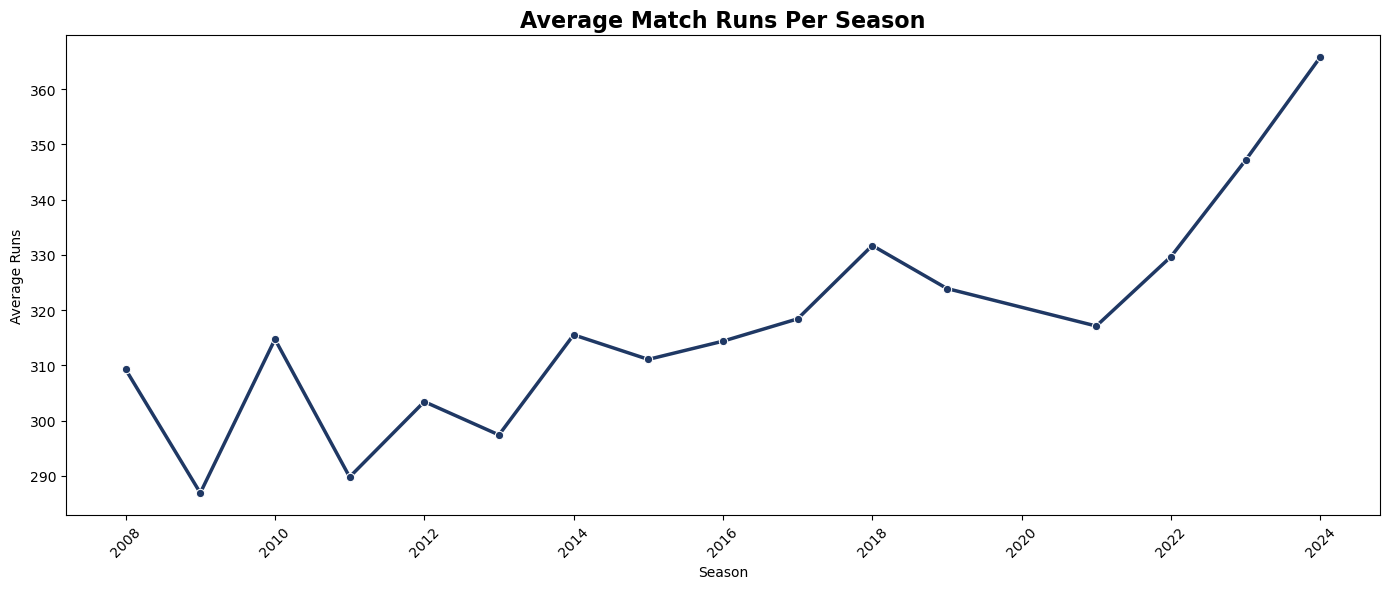

Done! Plot 4 saved!


In [7]:
# Analysis 4 - Season wise total runs
season_runs = deliveries.groupby('match_id').agg({'total_runs': 'sum'}).reset_index()
season_runs = season_runs.merge(matches[['id', 'season']], left_on='match_id', right_on='id')
season_avg = season_runs.groupby('season')['total_runs'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=season_avg, x='season', y='total_runs', marker='o', color='#1F3864', linewidth=2.5)
plt.title('Average Match Runs Per Season', fontsize=16, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Average Runs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('data/plot4_season_runs.png', dpi=150)
plt.show()
print("Done! Plot 4 saved!")

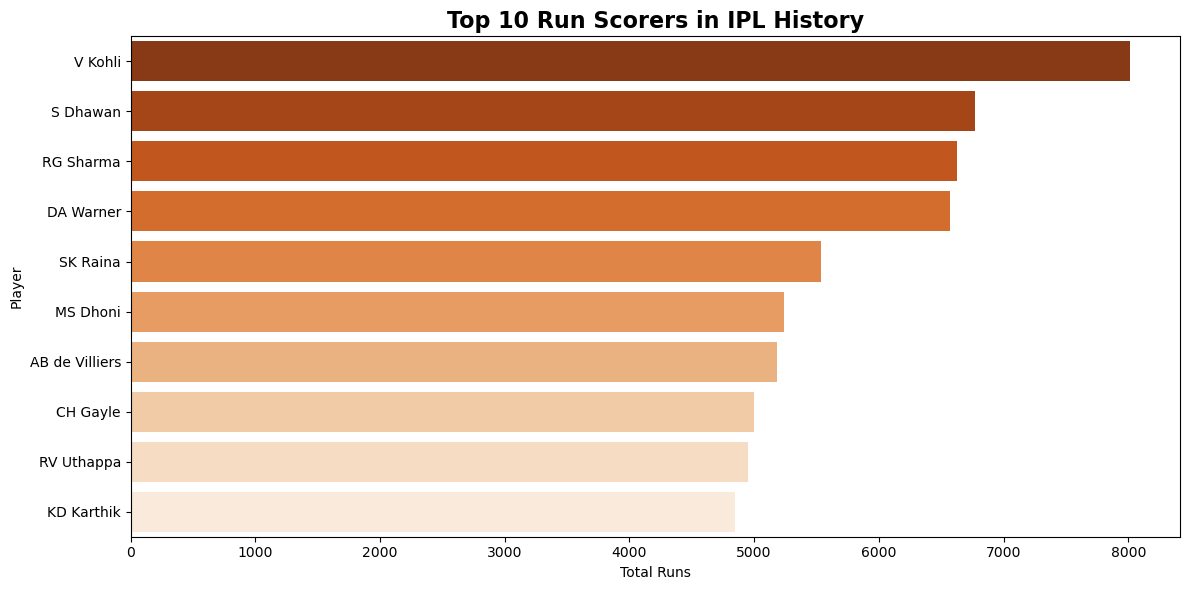

Done! Plot 5 saved!


In [8]:
# Analysis 5 - Top 10 run scorers
top_batsmen = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette='Oranges_r')
plt.title('Top 10 Run Scorers in IPL History', fontsize=16, fontweight='bold')
plt.xlabel('Total Runs')
plt.ylabel('Player')
plt.tight_layout()
plt.savefig('data/plot5_top_batsmen.png', dpi=150)
plt.show()
print("Done! Plot 5 saved!")

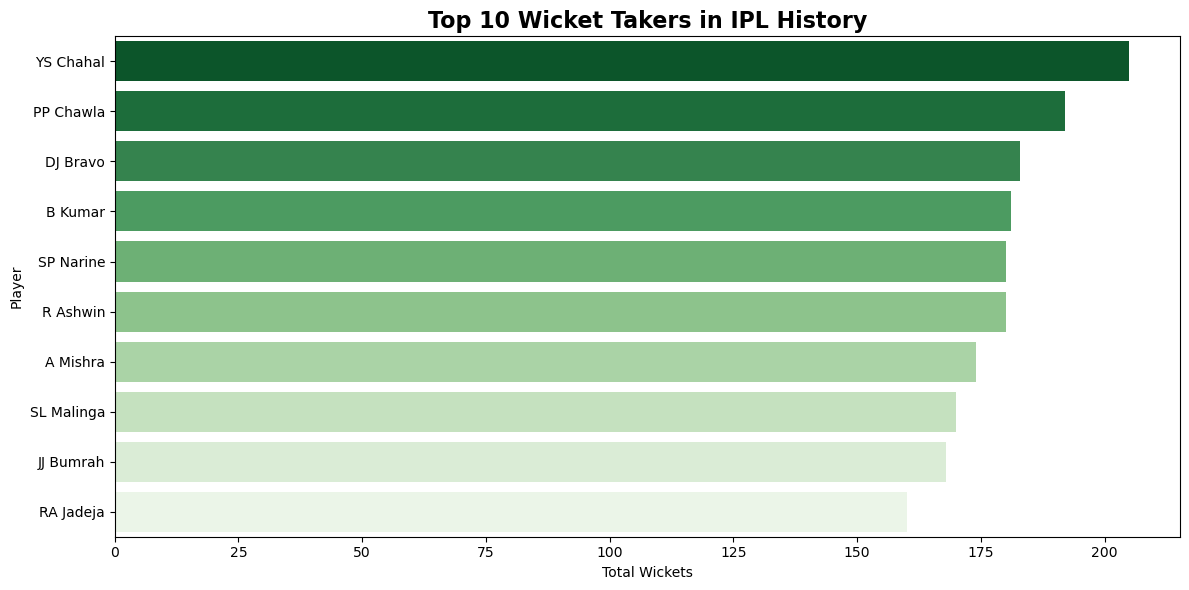

Done! Plot 6 saved!


In [9]:
# Analysis 6 - Top 10 wicket takers
top_bowlers = deliveries[deliveries['dismissal_kind'].notna()]
top_bowlers = top_bowlers[~top_bowlers['dismissal_kind'].isin(['run out', 'retired hurt', 'obstructing the field'])]
top_bowlers = top_bowlers.groupby('bowler')['dismissal_kind'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette='Greens_r')
plt.title('Top 10 Wicket Takers in IPL History', fontsize=16, fontweight='bold')
plt.xlabel('Total Wickets')
plt.ylabel('Player')
plt.tight_layout()
plt.savefig('data/plot6_top_bowlers.png', dpi=150)
plt.show()
print("Done! Plot 6 saved!")

In [10]:
import os
plots = [f for f in os.listdir('data') if f.endswith('.png')]
print("Plots saved:", plots)
print("\nTotal plots:", len(plots))

Plots saved: ['plot3_top_players.png', 'plot6_top_bowlers.png', 'plot2_toss_impact.png', 'plot5_top_batsmen.png', 'plot4_season_runs.png', 'plot1_team_wins.png']

Total plots: 6
